In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("DateFruit_Dataset.csv")

In [3]:
df.head() # 34 features, 1 category

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [4]:
df.shape

(898, 35)

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
df["Class"].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# PCA 
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.fit_transform(X_test_scaled)

In [11]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

### ANN

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [13]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [14]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [15]:
# Build our model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
model = ANN()

# loss & optim
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [17]:
# Training the NN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criteria(outputs, yb)
        loss.backward()
        optimizer.step() # params update

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criteria(outputs, yb)
            running_val_loss += loss.item()
            
    val_loss = running_val_loss / len(test_loader)
    val_losses.append(val_loss)

    print(f"epoch = {epoch+1}/{epochs} ==> train loss = {train_loss} & val loss = {val_loss}" )

    if (val_loss < best_val_loss):
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch = 1/100 ==> train loss = 1.6968689638635386 & val loss = 1.3957090973854065
epoch = 2/100 ==> train loss = 1.0947547036668528 & val loss = 0.8567807575066885
epoch = 3/100 ==> train loss = 0.7129251231317935 & val loss = 0.6015353997548422
epoch = 4/100 ==> train loss = 0.5261011369850325 & val loss = 0.4665120095014572
epoch = 5/100 ==> train loss = 0.42106064765349677 & val loss = 0.3849585677186648
epoch = 6/100 ==> train loss = 0.3593563975199409 & val loss = 0.3530307859182358
epoch = 7/100 ==> train loss = 0.32413139032280963 & val loss = 0.3054932802915573
epoch = 8/100 ==> train loss = 0.28872786591882293 & val loss = 0.2949149360259374
epoch = 9/100 ==> train loss = 0.2731858608515366 & val loss = 0.26630635062853497
epoch = 10/100 ==> train loss = 0.24984351124452508 & val loss = 0.2512248307466507
epoch = 11/100 ==> train loss = 0.23528137932653012 & val loss = 0.24049645413955054
epoch = 12/100 ==> train loss = 0.22665743853734888 & val loss = 0.23303374648094177
epoc

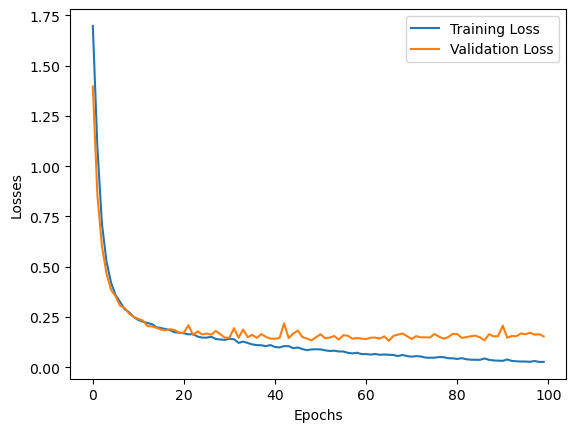

In [18]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [19]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [20]:
# Evaluate
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb) # [0.2, 0.5, 1.3, -0.5, ..] -7 vals
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == yb).sum().item()
        total += yb.size(0) # actual samples  in each batch

print("accuracy: ", correct/total * 100)

accuracy:  96.11111111111111


In [21]:
y_test.shape

(180,)